<a href="https://colab.research.google.com/github/DaniAuliya/PORTO_BUSINESS_ANALYST/blob/main/CODE_ProductsCocoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
from os import sep
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
!wget -O data_products.csv "https://raw.githubusercontent.com/DaniAuliya/PORTO_BUSINESS_ANALYST/main/products.csv"

--2026-06-06 14:43:45--  https://raw.githubusercontent.com/DaniAuliya/PORTO_BUSINESS_ANALYST/main/products.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9552 (9.3K) [text/plain]
Saving to: ‘data_products.csv’

data_products.csv   100%[===================>]   9.33K  --.-KB/s    in 0s      

2026-06-06 14:43:46 (75.6 MB/s) - ‘data_products.csv’ saved [9552/9552]



In [4]:
data = pd.read_csv("data_products.csv")
data.head(20)

,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50
5,P0006,Milk Chocolate 50%,Hershey,Dark,50,50
6,P0007,Praline Chocolate 70%,Cadbury,Praline,70,120
7,P0008,White Chocolate 90%,Godiva,Dark,90,100
8,P0009,White Chocolate 50%,Ferrero,Dark,50,80
9,P0010,Milk Chocolate 70%,Hershey,Truffle,70,50


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     200 non-null    object
 1   product_name   200 non-null    object
 2   brand          200 non-null    object
 3   category       200 non-null    object
 4   cocoa_percent  200 non-null    int64 
 5   weight_g       200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB


In [6]:
data.describe()

,cocoa_percent,weight_g
count,200.000000,200.000000
mean,69.150000,107.500000
std,14.623499,50.898954
min,50.000000,50.000000
25%,50.000000,80.000000
50%,70.000000,100.000000
75%,80.000000,120.000000
max,90.000000,200.000000


In [8]:
# Cek Missing Value
missing = pd.DataFrame({
    'Missing': data.isnull().sum(),
    'Percent': data.isnull().mean()*100
})

missing.sort_values('Percent', ascending=False)

,Missing,Percent
product_id,0,0.0
product_name,0,0.0
brand,0,0.0
category,0,0.0
cocoa_percent,0,0.0
weight_g,0,0.0


In [9]:
print("Jumlah Baris dan Kolom:")
print(data.shape)

print("\nNama Variabel:")
print(data.columns)

print("\nTipe Data:")
print(data.dtypes)

Jumlah Baris dan Kolom:
(200, 6)

Nama Variabel:
Index(['product_id', 'product_name', 'brand', 'category', 'cocoa_percent',
       'weight_g'],
      dtype='object')

Tipe Data:
product_id       object
product_name     object
brand            object
category         object
cocoa_percent     int64
weight_g          int64
dtype: object


#EDA

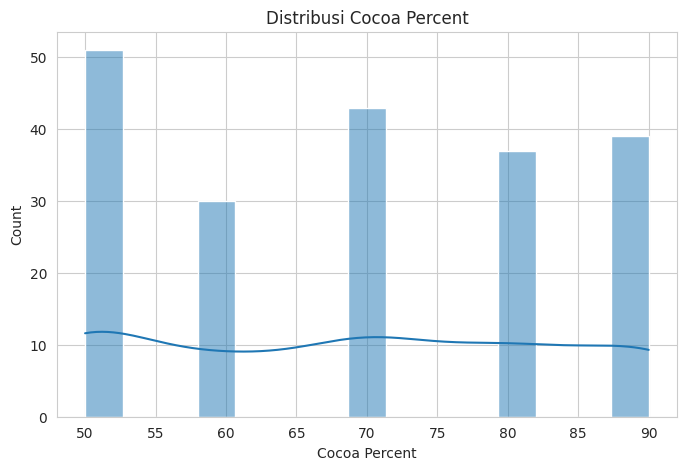

In [10]:
# Distribusi Cocoa Percent
plt.figure(figsize=(8,5))

sns.histplot(data['cocoa_percent'],
             bins=15,
             kde=True)

plt.title('Distribusi Cocoa Percent')
plt.xlabel('Cocoa Percent')
plt.show()

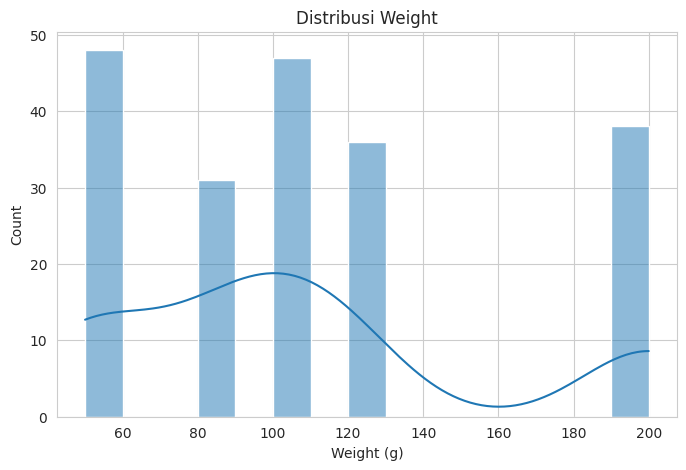

In [11]:
# Distribusi Weight
plt.figure(figsize=(8,5))

sns.histplot(data['weight_g'],
             bins=15,
             kde=True)

plt.title('Distribusi Weight')
plt.xlabel('Weight (g)')
plt.show()

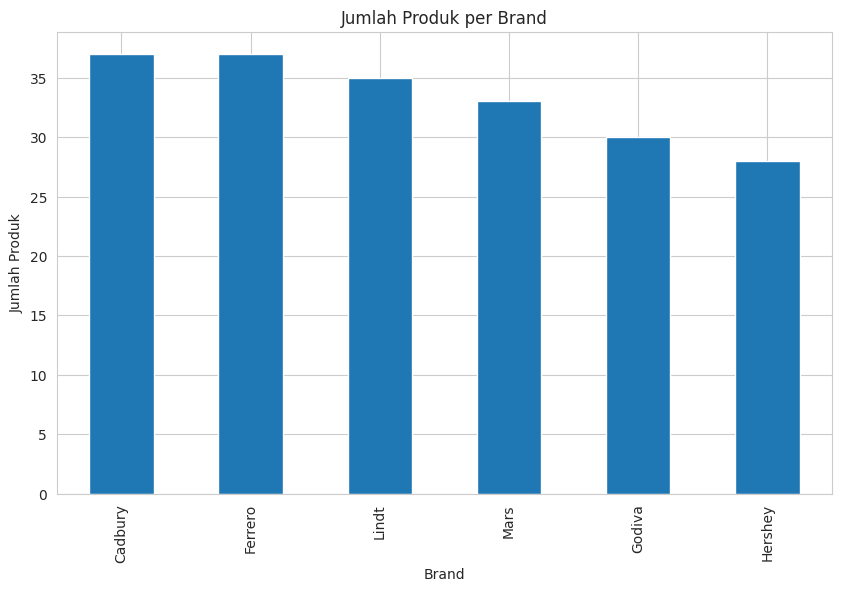

In [18]:
# Distribusi Brand
plt.figure(figsize=(10,6))

data['brand'].value_counts().plot(kind='bar')

plt.title('Jumlah Produk per Brand')
plt.xlabel('Brand')
plt.ylabel('Jumlah Produk')
plt.show()

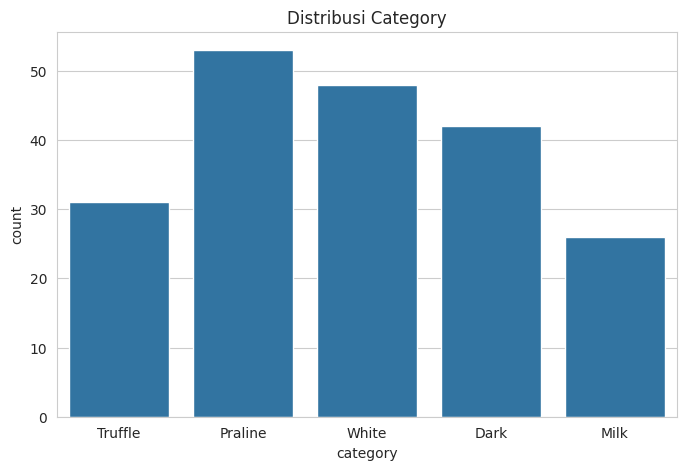

In [20]:
# Distribusi Category
plt.figure(figsize=(8,5))

sns.countplot(data=data,
              x='category')

plt.title('Distribusi Category')
plt.show()

**Boxplot Outlier**

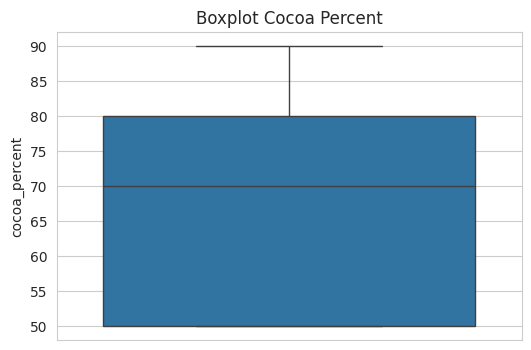

In [13]:
# Cocoa Percent
plt.figure(figsize=(6,4))

sns.boxplot(y=data['cocoa_percent'])

plt.title('Boxplot Cocoa Percent')
plt.show()

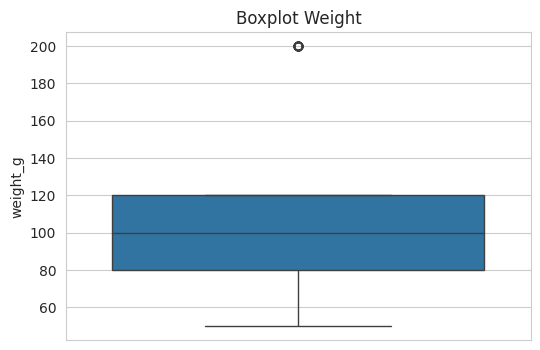

In [15]:
# Weight
plt.figure(figsize=(6,4))

sns.boxplot(y=data['weight_g'])

plt.title('Boxplot Weight')
plt.show()

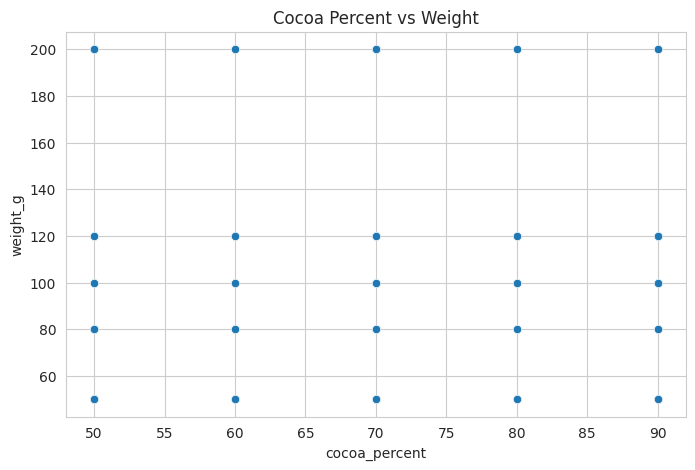

In [22]:
# Hubungan Cocoa dan Weight
plt.figure(figsize=(8,5))

sns.scatterplot(data=data,
                x='cocoa_percent',
                y='weight_g')

plt.title('Cocoa Percent vs Weight')
plt.show()

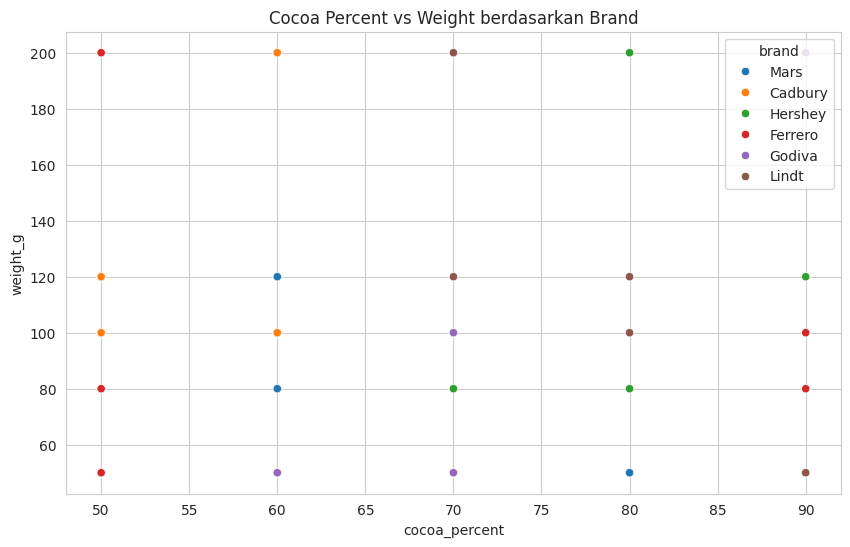

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=data,
                x='cocoa_percent',
                y='weight_g',
                hue='brand')

plt.title('Cocoa Percent vs Weight berdasarkan Brand')
plt.show()

In [25]:
corr = data[['cocoa_percent','weight_g']].corr()

print(corr)

               cocoa_percent  weight_g
cocoa_percent       1.000000  0.003207
weight_g            0.003207  1.000000


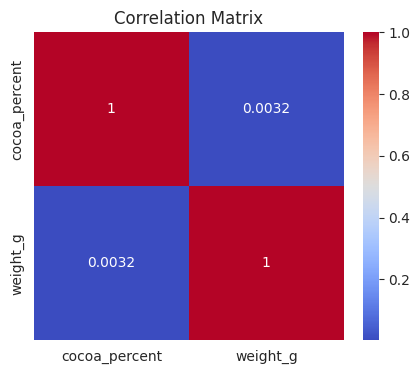

In [26]:
plt.figure(figsize=(5,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [27]:
# Rata-rata Cocoa Tiap Brand
data.groupby('brand')['cocoa_percent'].mean().sort_values(ascending=False)

,cocoa_percent
brand,
Lindt,72.285714
Godiva,70.333333
Cadbury,69.729730
Mars,69.393939
Hershey,69.285714
Ferrero,64.324324


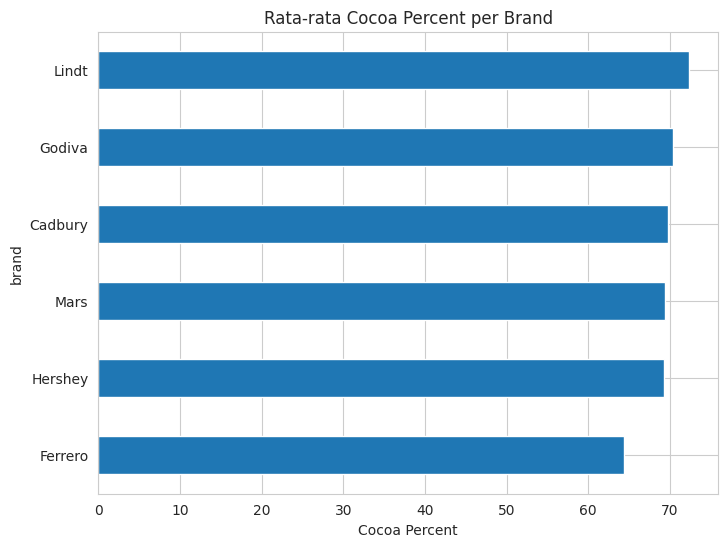

In [28]:
avg_cocoa = (
    data.groupby('brand')['cocoa_percent']
    .mean()
    .sort_values()
)

avg_cocoa.plot(kind='barh',
               figsize=(8,6))

plt.title('Rata-rata Cocoa Percent per Brand')
plt.xlabel('Cocoa Percent')
plt.show()

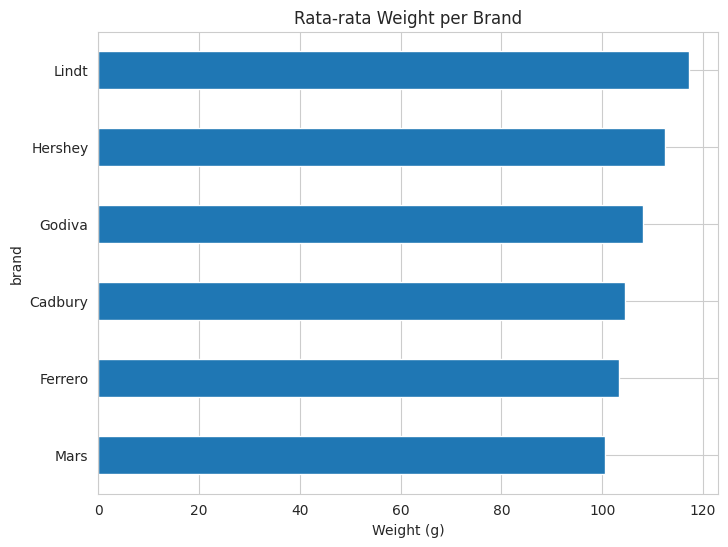

In [30]:
# Rata-rata Weight Tiap Brand
avg_weight = (
    data.groupby('brand')['weight_g']
    .mean()
    .sort_values()
)

avg_weight.plot(kind='barh',
                figsize=(8,6))

plt.title('Rata-rata Weight per Brand')
plt.xlabel('Weight (g)')
plt.show()

In [31]:
# Crosstab Brand & Category
pd.crosstab(data['brand'],
            data['category'])

category,Dark,Milk,Praline,Truffle,White
brand,,,,,
Cadbury,6,5,8,5,13
Ferrero,10,6,8,6,7
Godiva,7,5,8,5,5
Hershey,7,2,7,6,6
Lindt,7,6,10,5,7
Mars,5,2,12,4,10


# CLUSTERING

In [32]:
from sklearn.preprocessing import StandardScaler

X = data[['cocoa_percent',
        'weight_g']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

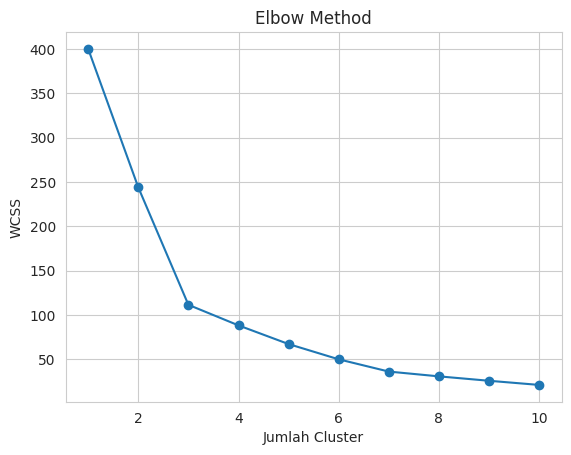

In [33]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    km = KMeans(n_clusters=k,
                random_state=42,
                n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Jumlah Cluster")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [34]:
from sklearn.metrics import silhouette_score

for k in range(2,8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(f"K={k}, Silhouette={score:.3f}")

K=2, Silhouette=0.471
K=3, Silhouette=0.526
K=4, Silhouette=0.453
K=5, Silhouette=0.479
K=6, Silhouette=0.499
K=7, Silhouette=0.544


In [36]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

data['cluster'] = kmeans.fit_predict(X_scaled)

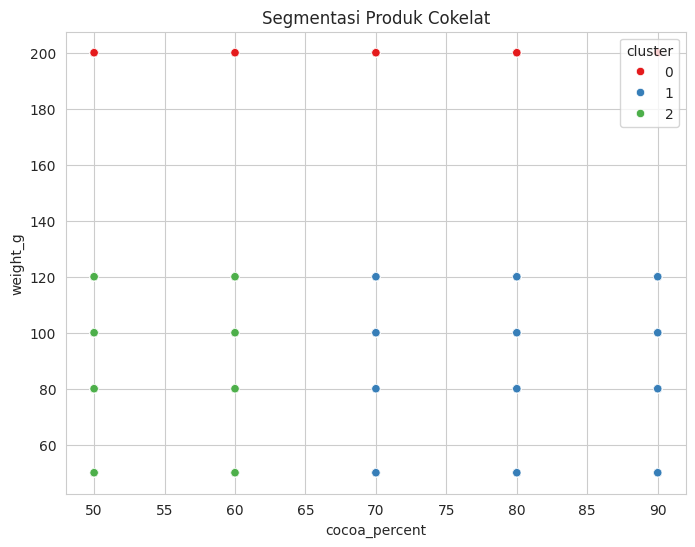

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x='cocoa_percent',
    y='weight_g',
    hue='cluster',
    palette='Set1'
)

plt.title("Segmentasi Produk Cokelat")
plt.show()

In [39]:
data.groupby('cluster')[
    ['cocoa_percent','weight_g']
].mean()

,cocoa_percent,weight_g
cluster,,
0,67.894737,200.000000
1,80.638298,88.085106
2,53.970588,82.647059


# PCA

In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    pca.explained_variance_ratio_
)

[0.50160343 0.49839657]


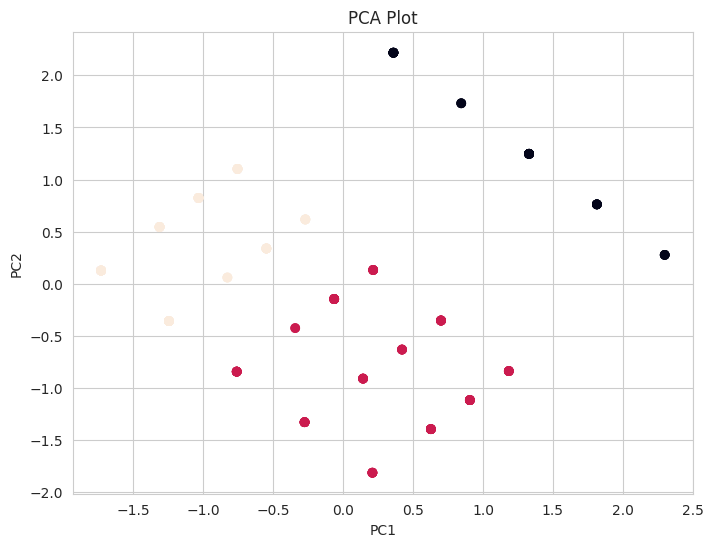

In [42]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=data['cluster']
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Plot')
plt.show()

# KLASIFIKASI CATEGORY


In [44]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['category_enc'] = le.fit_transform(
    data['category']
)

In [45]:
# Split Data
from sklearn.model_selection import train_test_split

X = data[['cocoa_percent','weight_g']]
y = data['category_enc']

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [46]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

pred = rf.predict(X_test)

In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.25      0.33      0.29         6
           1       0.00      0.00      0.00         7
           2       0.13      0.25      0.17         8
           3       0.20      0.25      0.22         8
           4       0.50      0.27      0.35        11

    accuracy                           0.23        40
   macro avg       0.22      0.22      0.21        40
weighted avg       0.24      0.23      0.22        40



# MARKET INSIGHT

In [48]:
# Brand dengan cocoa tertinggi
data.groupby('brand')['cocoa_percent'] \
.mean() \
.sort_values(ascending=False)

,cocoa_percent
brand,
Lindt,72.285714
Godiva,70.333333
Cadbury,69.729730
Mars,69.393939
Hershey,69.285714
Ferrero,64.324324


In [50]:
# Category dengan berat terbesar
data.groupby('category')['weight_g'] \
.mean() \
.sort_values(ascending=False)

,weight_g
category,
Dark,119.285714
Milk,117.692308
White,106.458333
Truffle,102.258065
Praline,97.169811


In [52]:
# Distribusi Produk per Brand
data['brand'].value_counts()

,count
brand,
Cadbury,37
Ferrero,37
Lindt,35
Mars,33
Godiva,30
Hershey,28
